# Descent Directions and Line Search
### MECH 559 - Systems Optimization - L06

Companion notebook to the line-search half of the "Algorithms for continuous unconstrained optimization" lecture: what makes a direction a *descent* direction, why steepest descent can fail catastrophically with a fixed step of $\alpha=1$, and how exact and inexact (Armijo) line search fix that.

## Learning objectives

By the end, students should be able to:

1. Verify numerically whether a candidate direction $d_k$ is a descent direction ($\nabla f_k^{\mathrm T}d_k<0$).
2. Reproduce the lecture's steepest-descent oscillation example and explain it in terms of step size vs. curvature.
3. Implement the closed-form exact line search step $\alpha_k^\ast$ for the gradient method and see the classic "zigzag" on an ill-conditioned quadratic.
4. Implement Armijo backtracking from scratch and reproduce both worked examples from the slides.

> **Classroom rhythm:** pause at each **Predict** prompt, collect answers, then run the next cell.

In [12]:
import numpy as np
import matplotlib.pyplot as plt

try:
    import ipywidgets as widgets
    from IPython.display import display
    WIDGETS_AVAILABLE = True
except ImportError:
    WIDGETS_AVAILABLE = False

plt.rcParams.update({
    "font.size": 11,
    "figure.dpi": 110,
    "axes.grid": True,
    "grid.alpha": 0.25,
})

COLORS = {"boundary": "#00798C", "optimum": "#D1495B", "accent": "#EDAE49"}

print(f"NumPy {np.__version__}; optional widgets available: {WIDGETS_AVAILABLE}")

NumPy 2.5.0; optional widgets available: True


---
## 1. What makes a direction a descent direction?

Using the first-order approximation, $f_{k+1}-f_k \approx \nabla f_k^{\mathrm T} d_k$. A direction $d_k$ is a *descent direction* iff $\nabla f_k^{\mathrm T} d_k < 0$. Choosing $d_k=-\nabla f_k$ always works, since $\nabla f_k^{\mathrm T}(-\nabla f_k) = -\|\nabla f_k\|_2^2 \le 0$.

> **Predict:** for a *random* direction $d$ (not aligned with $-\nabla f_k$), what fraction of random directions in $\mathbb R^2$ do you expect to be descent directions?

In [13]:
def f(x):
    x1, x2 = x
    return x1**2 + 2*x2**2

def grad(x):
    x1, x2 = x
    return np.array([2*x1, 4*x2])

x0 = np.array([1.0, 1.0])
g0 = grad(x0)

rng = np.random.default_rng(0)
n_trials = 2000
descent_count = 0
for _ in range(n_trials):
    d = rng.normal(size=2)
    d = d / np.linalg.norm(d)
    if g0 @ d < 0:
        descent_count += 1
print(f"fraction of random unit directions that are descent directions: {descent_count/n_trials:.3f} (expect ~0.5)")

d_steepest = -g0 / np.linalg.norm(g0)
print(f"steepest descent direction gives grad^T d = {g0@d_steepest:.4f} (the most negative possible, by Cauchy-Schwarz)")

fraction of random unit directions that are descent directions: 0.515 (expect ~0.5)
steepest descent direction gives grad^T d = -4.4721 (the most negative possible, by Cauchy-Schwarz)


---
## 2. Steepest descent can oscillate forever

Reproducing the lecture's example: $\min_x f(x)=x^2$, steepest descent ($\alpha=1$) from $x_0=1$.

steepest descent (alpha=1) trajectory: ['1.000', '-1.000', '1.000', '-1.000', '1.000', '-1.000', '1.000']
It oscillates between +1 and -1 forever and never reaches x*=0.


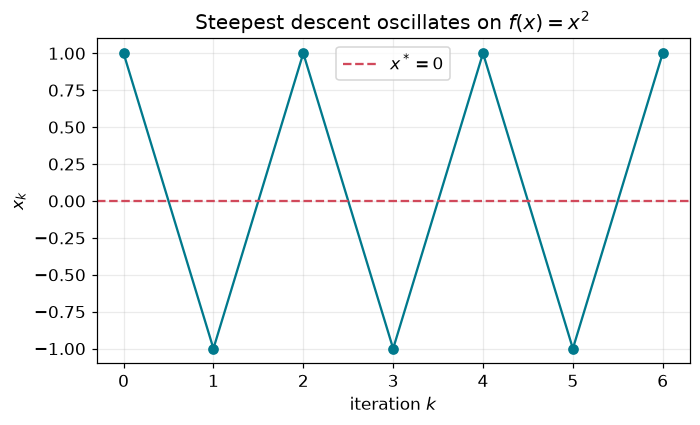

In [14]:
def steepest_descent_1d(x0, n_iter=6):
    x = x0
    traj = [x]
    for _ in range(n_iter):
        x = x - 2*x
        traj.append(x)
    return traj

traj = steepest_descent_1d(1.0)
print("steepest descent (alpha=1) trajectory:", [f"{v:.3f}" for v in traj])
print("It oscillates between +1 and -1 forever and never reaches x*=0.")

fig, ax = plt.subplots(figsize=(6.5, 4))
ax.plot(traj, marker="o", color=COLORS["boundary"])
ax.axhline(0, color=COLORS["optimum"], ls="--", label="$x^*=0$")
ax.set(xlabel="iteration $k$", ylabel="$x_k$", title="Steepest descent oscillates on $f(x)=x^2$")
ax.legend()
plt.tight_layout()
plt.show()

---
## 3. The gradient method: adding a step size $\alpha$

Since $f''(x)=2$ everywhere, the update is $x_{k+1}=(1-2\alpha)x_k$. Stability requires $|1-2\alpha|<1$, i.e. $0<\alpha<1$; $\alpha=1$ sits exactly on the boundary (sustained oscillation, as above) and $\alpha>1$ diverges.

> **Predict:** before running the cell, guess what happens for $\alpha=0.01$ (very small), $\alpha=0.4$, and $\alpha=1.2$.

alpha=0.01: ['1.000', '0.980', '0.960', '0.941', '0.922', '0.904', '0.886']
alpha=0.40: ['1.000', '0.200', '0.040', '0.008', '0.002', '0.000', '0.000']
alpha=1.00: ['1.000', '-1.000', '1.000', '-1.000', '1.000', '-1.000', '1.000']
alpha=1.20: ['1.000', '-1.400', '1.960', '-2.744', '3.842', '-5.378', '7.530']


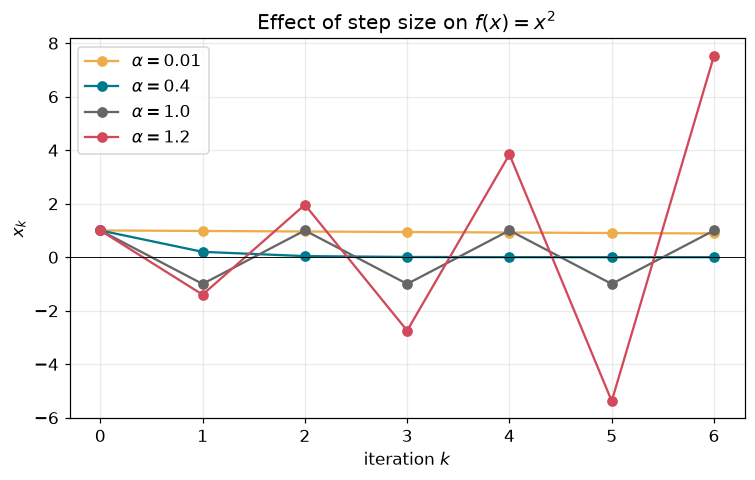

In [15]:
def gradient_method_1d(alpha, x0=1.0, n_iter=6):
    x = x0
    traj = [x]
    for _ in range(n_iter):
        x = x - alpha*2*x
        traj.append(x)
    return traj

fig, ax = plt.subplots(figsize=(7, 4.5))
for alpha, color in zip([0.01, 0.4, 1.0, 1.2], [COLORS["accent"], COLORS["boundary"], "0.4", COLORS["optimum"]]):
    traj = gradient_method_1d(alpha)
    ax.plot(traj, marker="o", color=color, label=f"$\\alpha={alpha}$")
    print(f"alpha={alpha:4.2f}: {['%.3f' % v for v in traj]}")
ax.axhline(0, color="black", lw=0.6)
ax.set(xlabel="iteration $k$", ylabel="$x_k$", title="Effect of step size on $f(x)=x^2$")
ax.legend()
plt.tight_layout()
plt.show()

---
## 4. Exact line search: the classic zigzag

For the gradient method, the exact line-search step has a closed form:
$$
\alpha_k^\ast = \frac{\nabla f_k^{\mathrm T}\nabla f_k}{\nabla f_k^{\mathrm T} H_k \nabla f_k}.
$$
On an *ill-conditioned* quadratic, steepest descent with exact line search still zigzags badly - exact line search fixes the *step size* at each iteration, not the fundamental problem that $-\nabla f_k$ is a poor direction when the Hessian is elongated.

converged after 71 iterations; condition number of A = 10.0


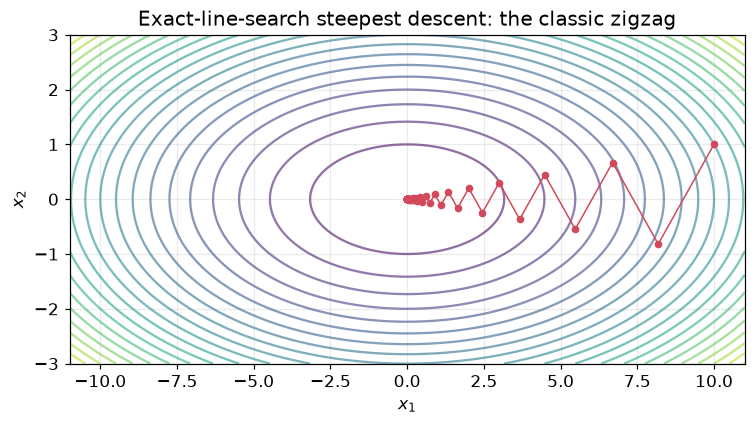

In [16]:
A = np.diag([1.0, 10.0])

def f_quad(x):
    return 0.5 * x @ A @ x

def exact_line_search_gd(A, x0, n_iter=300, tol=1e-10):
    x = x0.astype(float).copy()
    traj = [x.copy()]
    for _ in range(n_iter):
        g = A @ x
        if g @ g < tol:
            return np.array(traj), True
        alpha = (g @ g) / (g @ A @ g)
        x = x - alpha * g
        traj.append(x.copy())
    return np.array(traj), False

traj, converged = exact_line_search_gd(A, np.array([10.0, 1.0]))
status = "converged" if converged else "did not fully converge (still zigzagging slowly)"
print(f"{status} after {len(traj)-1} iterations; condition number of A = {np.linalg.cond(A):.1f}")

x1g, x2g = np.meshgrid(np.linspace(-11, 11, 200), np.linspace(-3, 3, 200))
Z = 0.5*(A[0,0]*x1g**2 + A[1,1]*x2g**2)
fig, ax = plt.subplots(figsize=(7, 4))
ax.contour(x1g, x2g, Z, levels=25, cmap="viridis", alpha=0.6)
ax.plot(traj[:, 0], traj[:, 1], marker="o", color=COLORS["optimum"], markersize=4, lw=1)
ax.set(xlabel="$x_1$", ylabel="$x_2$", title="Exact-line-search steepest descent: the classic zigzag")
plt.tight_layout()
plt.show()

---
## 5. Armijo-Goldstein: bounding acceptable step sizes

The two Goldstein conditions bound $\phi(\alpha)=f(x_k+\alpha d_k)$ between two lines through $(0,\phi(0))$ with slopes $\epsilon_1\phi'(0)$ and $\epsilon_2\phi'(0)$ (with $\epsilon_2=1-\epsilon_1$, $\epsilon_1\in(0,0.5)$), giving an acceptable interval $[\alpha_C,\alpha_B]$.

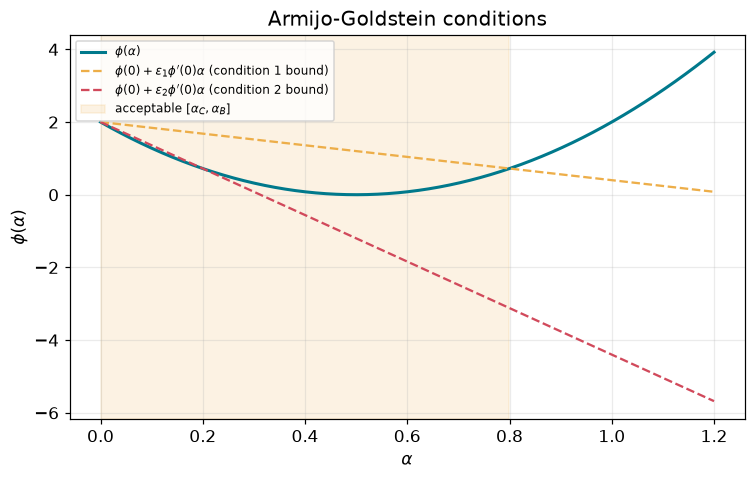

In [17]:
def phi(alpha, x, d, func):
    return func(x + alpha*d)

x = np.array([1.0, 1.0])
d = np.array([-2.0, -2.0])  # -grad of f(x)=x1^2+x2^2 at (1,1)

def f_simple(x):
    return x[0]**2 + x[1]**2

phi0 = f_simple(x)
dphi0 = np.array([2*x[0], 2*x[1]]) @ d
eps1, eps2 = 0.2, 0.8

alphas = np.linspace(0, 1.2, 300)
phi_vals = np.array([phi(a, x, d, f_simple) for a in alphas])
line1 = phi0 + eps1*dphi0*alphas
line2 = phi0 + eps2*dphi0*alphas

fig, ax = plt.subplots(figsize=(7, 4.5))
ax.plot(alphas, phi_vals, color=COLORS["boundary"], lw=2, label=r"$\phi(\alpha)$")
ax.plot(alphas, line1, color=COLORS["accent"], ls="--", label=r"$\phi(0)+\epsilon_1\phi'(0)\alpha$ (condition 1 bound)")
ax.plot(alphas, line2, color=COLORS["optimum"], ls="--", label=r"$\phi(0)+\epsilon_2\phi'(0)\alpha$ (condition 2 bound)")
acceptable = (phi_vals <= line1) & (phi_vals >= line2)
if acceptable.any():
    ax.axvspan(alphas[acceptable][0], alphas[acceptable][-1], color=COLORS["accent"], alpha=0.15, label="acceptable $[\\alpha_C,\\alpha_B]$")
ax.set(xlabel=r"$\alpha$", ylabel=r"$\phi(\alpha)$", title="Armijo-Goldstein conditions")
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

---
## 6. Armijo backtracking from scratch

Implement the slide's algorithm directly: start from a large $\alpha_0$ and shrink it by a factor $\beta$ until the sufficient-decrease condition holds.

In [18]:
def armijo_backtrack(func, grad_func, x, d, alpha0=1.0, eps=0.1, beta=0.85, max_iter=60):
    phi0 = func(x)
    dphi0 = grad_func(x) @ d
    alpha = alpha0
    for _ in range(max_iter):
        if func(x + alpha*d) <= phi0 + eps*alpha*dphi0:
            return alpha
        alpha *= beta
    return alpha

# --- Example 1 from the slides: f = x1^2 + x2^2, x_k = [1,1] ---
def f1(x):
    return x[0]**2 + x[1]**2

def g1(x):
    return np.array([2*x[0], 2*x[1]])

x = np.array([1.0, 1.0])
d = -g1(x)
alpha = armijo_backtrack(f1, g1, x, d, alpha0=1.0, eps=0.1, beta=0.85)
print(f"Example 1: accepted alpha = {alpha:.4f}  (slide's derived range: 0.45 <= alpha <= 0.9)")

x_run = x.copy()
for k in range(30):
    g = g1(x_run)
    if np.linalg.norm(g) < 1e-8:
        break
    alpha = armijo_backtrack(f1, g1, x_run, -g)
    x_run = x_run - alpha*g
print(f"Example 1: full run converges to {x_run} in {k} outer iterations (global min is [0,0])")

# --- Example 2 from the slides: f = 4x1^2+3x1x2+x2^2, x_k = [1,-2] ---
def f2(x):
    return 4*x[0]**2 + 3*x[0]*x[1] + x[1]**2

def g2(x):
    return np.array([8*x[0]+3*x[1], 3*x[0]+2*x[1]])

x2 = np.array([1.0, -2.0])
d2 = -g2(x2)
alpha2 = armijo_backtrack(f2, g2, x2, d2, alpha0=1.0, eps=0.15, beta=0.85)
print(f"\nExample 2: grad at x_k = {g2(x2)}, accepted alpha = {alpha2:.4f}, x_(k+1) = {x2 + alpha2*d2}")

x2_run = x2.copy()
for k in range(30):
    g = g2(x2_run)
    if np.linalg.norm(g) < 1e-8:
        break
    alpha = armijo_backtrack(f2, g2, x2_run, -g, eps=0.15)
    x2_run = x2_run - alpha*g
print(f"Example 2: full run converges to {x2_run} in {k} outer iterations (global min is [0,0])")

Example 1: accepted alpha = 0.8500  (slide's derived range: 0.45 <= alpha <= 0.9)
Example 1: full run converges to [2.25393403e-05 2.25393403e-05] in 29 outer iterations (global min is [0,0])

Example 2: grad at x_k = [ 2. -1.], accepted alpha = 0.3771, x_(k+1) = [ 0.24570097 -1.62285048]
Example 2: full run converges to [ 0.0075047  -0.01188204] in 29 outer iterations (global min is [0,0])


---
## 7. Interactive: Armijo backtracking

Change $\epsilon$ and $\beta$ and watch how many backtracking steps it takes to accept a step, and how large the accepted $\alpha$ ends up being.

In [19]:
def armijo_demo(eps=0.1, beta=0.85, alpha0=1.0):
    x = np.array([1.0, -2.0])
    g = g2(x)
    d = -g
    phi0 = f2(x)
    dphi0 = g @ d
    alpha = alpha0
    trials = [alpha]
    for _ in range(60):
        if f2(x + alpha*d) <= phi0 + eps*alpha*dphi0:
            break
        alpha *= beta
        trials.append(alpha)
    alphas_plot = np.linspace(0, alpha0*1.05, 200)
    phi_vals = np.array([f2(x + a*d) for a in alphas_plot])
    line = phi0 + eps*dphi0*alphas_plot
    fig, ax = plt.subplots(figsize=(6.5, 4))
    ax.plot(alphas_plot, phi_vals, color=COLORS["boundary"], label=r"$\phi(\alpha)$")
    ax.plot(alphas_plot, line, color=COLORS["accent"], ls="--", label="sufficient-decrease bound")
    ax.scatter(trials, [f2(x + a*d) for a in trials], color="0.4", s=25, zorder=3, label="backtracking trials")
    ax.scatter([alpha], [f2(x + alpha*d)], color=COLORS["optimum"], s=80, zorder=4, label="accepted")
    ax.legend(fontsize=8)
    plt.tight_layout()
    plt.show()
    print(f"accepted alpha = {alpha:.5f} after {len(trials)} trial(s)")

if WIDGETS_AVAILABLE:
    display(widgets.interactive(armijo_demo,
                                 eps=widgets.FloatSlider(value=0.1, min=0.01, max=0.49, step=0.01),
                                 beta=widgets.FloatSlider(value=0.85, min=0.5, max=0.95, step=0.05),
                                 alpha0=widgets.FloatSlider(value=1.0, min=0.5, max=3.0, step=0.25)))
else:
    print("ipywidgets is not installed; running the default case.")
    armijo_demo()

interactive(children=(FloatSlider(value=0.1, description='eps', max=0.49, min=0.01, step=0.01), FloatSlider(va…

---
## Takeaways

1. A direction is a descent direction exactly when $\nabla f_k^{\mathrm T}d_k<0$; $d_k=-\nabla f_k$ is the *steepest* such direction but not the only one.
2. Steepest descent with a fixed step of $\alpha=1$ can oscillate forever even on the simplest possible quadratic - the step size matters as much as the direction.
3. Exact line search removes the guesswork in choosing $\alpha$, but does not fix the deeper issue of an ill-conditioned Hessian - the zigzag persists.
4. Armijo backtracking is cheap (no Hessian, no exact 1-D solve) and, combined with gradient descent, reliably converges on both worked examples from the slides.

## Optional exercises

1. Find, by hand or numerically, the exact boundary value of $\alpha$ at which the 1-D gradient method transitions from oscillating-but-convergent to diverging for $f(x)=cx^2$, as a function of $c$.
2. Modify the exact-line-search demo to use $A=\mathrm{diag}(1,100)$ (condition number 100). How many iterations does it take now?
3. In the Armijo backtracking demo, set $\epsilon$ very close to $0.5$. What happens to the number of backtracking trials needed, and why?